Number of components found: 1


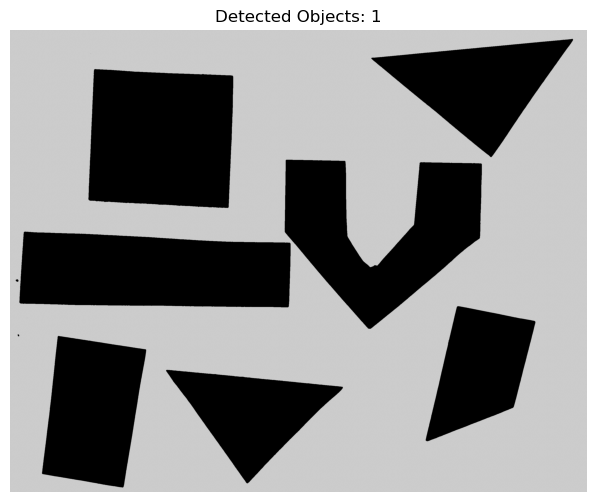

In [30]:
import matplotlib.pyplot as plt
from skimage import io, filters, measure, color
import numpy as np

# 1. Load the image
# io.imread converts the file into a numpy array
img = io.imread("shapes-01.jpg")

# 2. Pre-processing
# Convert to grayscale if it's an RGB image
if img.ndim == 3:
    img_gray = color.rgb2gray(img)
else:
    img_gray = img

# 3. Apply Gaussian Filter (using your sigma=2.0)
img_blurred = filters.gaussian(img_gray, sigma=2.0)

# 4. Thresholding (using your t=0.9)
# Creates a binary image where pixels > 0.9 are True (1)
binary_img = img_blurred > 0.9

# 5. Connected Components Labeling
# connectivity=2 in 2D means 8-connectivity (diagonal pixels included)
labeled_image, count = measure.label(binary_img, connectivity=2, return_num=True)

# 6. Visualization
print(f"Number of components found: {count}")

fig, ax = plt.subplots(figsize=(8, 6))
# Using 'nipy_spectral' helps distinguish different labels clearly
plt.imshow(labeled_image, cmap='nipy_spectral')
plt.axis("off")
plt.title(f"Detected Objects: {count}")
plt.show()

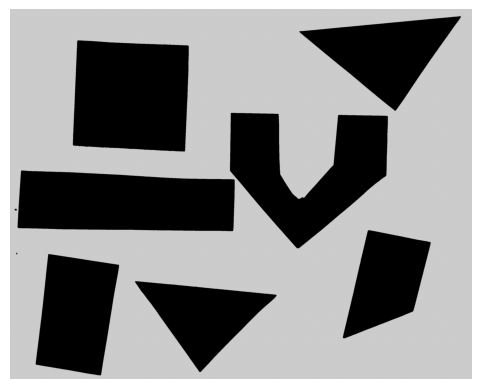

Total objects found: 1


In [31]:
import matplotlib.pyplot as plt
import skimage as ski
import imageio.v3 as iio  # Often used in modern lecture notes

def connected_components(filename, sigma=1.0, t=0.5, connectivity=2):
    # 1. Load the image
    image = iio.imread(filename)
    
    # 2. Convert to grayscale if necessary
    if image.ndim == 3:
        gray_image = ski.color.rgb2gray(image)
    else:
        gray_image = image
        
    # 3. Denoise with Gaussian filter
    blurred_image = ski.filters.gaussian(gray_image, sigma=sigma)
    
    # 4. Create a binary mask using threshold t
    binary_mask = blurred_image > t
    
    # 5. Label and count connected components
    # connectivity=2 corresponds to 8-neighbor connectivity
    labeled_image, count = ski.measure.label(binary_mask, connectivity=connectivity, return_num=True)
    
    return labeled_image, count

# Now your original code will run perfectly:
labeled_image, count = connected_components(filename="shapes-01.jpg", sigma=2.0, t=0.9, connectivity=2)

fig, ax = plt.subplots()
plt.imshow(labeled_image, cmap='nipy_spectral') # Added color for better visualization
plt.axis("off")
plt.show()

print(f"Total objects found: {count}")

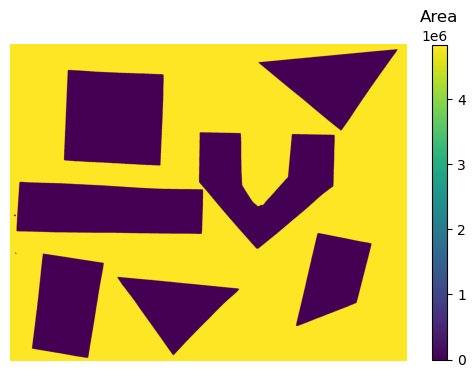

In [32]:
import skimage
object_areas = np.array([objf["area"] for objf in skimage.measure.regionprops(labeled_image)])
object_areas = np.insert(0,1,object_areas)
colored_area_image = object_areas[labeled_image]
fig, ax = plt.subplots()
im = plt.imshow(colored_area_image)
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.ax.set_title("Area")
plt.axis("off");


In [33]:
object_features = skimage.measure.regionprops(labeled_image)
object_areas = [objf["area"] for objf in object_features]
object_areas

[np.float64(4821419.0)]

In [34]:
min_area = 200
object_areas = np.array([objf["area"] for objf in object_features])
object_labels = np.array([objf["label"] for objf in object_features])
large_objects = object_labels[object_areas > min_area]
print("Found", len(large_objects), "objects!")

# n = np.count_nonzero(object_areas > min_area)
# print("Found", n, "objects!")

Found 1 objects!


In [35]:

n = np.count_nonzero(object_areas > min_area)
print("Found", n, "objects!")


Found 1 objects!


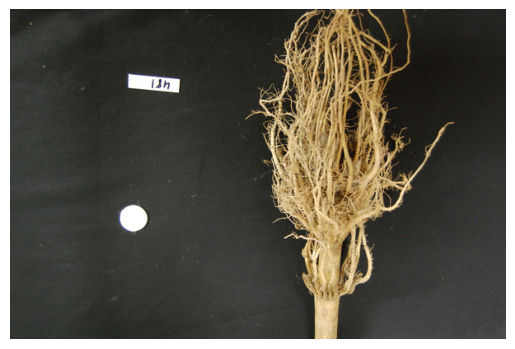

In [36]:

maize_roots = plt.imread('maize-root-cluster.jpg')

fig, ax = plt.subplots()
plt.imshow(maize_roots)
plt.axis("off");
plt.show()


In [37]:
t = skimage.filters.threshold_otsu(blurred_image)
print("Found automatic threshold t = {}.".format(t))

Found automatic threshold t = 0.4031121731580994.


/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_17661/3910911817.py:1: UserWarning: threshold_otsu is expected to work correctly only for grayscale images; image shape (400, 602, 3) looks like that of an RGB image.
  t = skimage.filters.threshold_otsu(blurred_image)


In [38]:
blurred_image = skimage.filters.gaussian(maize_roots, sigma=1.0)
t = skimage.filters.threshold_otsu(blurred_image)
print("Found automatic threshold t = {}.".format(t))
print(t)

Found automatic threshold t = 0.4031121731580994.
0.4031121731580994


/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_17661/762736028.py:2: UserWarning: threshold_otsu is expected to work correctly only for grayscale images; image shape (400, 602, 3) looks like that of an RGB image.
  t = skimage.filters.threshold_otsu(blurred_image)


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


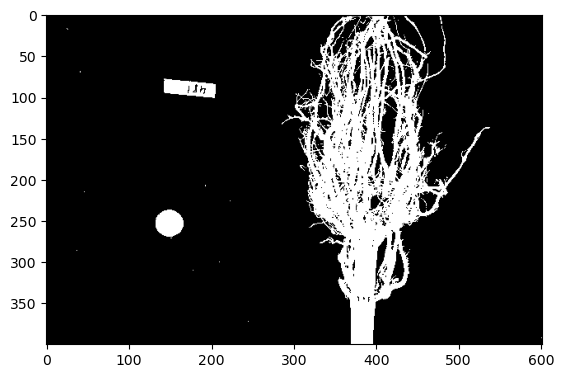

In [39]:
grey_iamge = color.rgb2gray(maize_roots)

binary_mask = (grey_iamge > t).astype(float)

fig, ax = plt.subplots()
plt.imshow(binary_mask, cmap="gray")
print(binary_mask)

In [40]:
def measure_root_mass(filename, sigma=1.0):
    # read the original image, converting to grayscale on the fly
    image = iio.imread(uri=filename, mode="L") # “L” = automatic convert to gray
    # blur before thresholding
    blurred_image = skimage.filters.gaussian(image, sigma=sigma)
    # perform automatic thresholding to produce a binary image
    t = skimage.filters.threshold_otsu(blurred_image)
    binary_mask = blurred_image > t
    # determine root mass ratio
    rootPixels = np.count_nonzero(binary_mask)
    w = binary_mask.shape[1]
    h = binary_mask.shape[0]
    density = rootPixels / (w * h)
    return density


In [43]:
measure_root_mass(filename="/Users/zehra/Desktop/AI-Humber/secsem/imagepros/trial-016.jpg", sigma=1.5)

all_files = glob.glob("data/trial-*.jpg")
for filename in all_files:
    density = measure_root_mass(filename=filename, sigma=1.5)
    # output in format suitable for .csv
    print(filename, density, sep=",")



NameError: name 'glob' is not defined